# CS3807 – Deep Learning Laboratory
## Experiment 6: End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

## 1. Imports and Setup

In [1]:
import os
import time
import math
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout, Input,
    RepeatVector, TimeDistributed, Embedding
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

ACTIVITY_LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]


## 2. Dataset Download – UCI HAR Using Smartphones

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ROOT_DIR = "."
OUTER_ZIP = "har_outer.zip"
DATA_DIR = os.path.join(ROOT_DIR, "UCI HAR Dataset")

if not os.path.isdir(DATA_DIR):
    print("Downloading UCI HAR dataset ...")
    urllib.request.urlretrieve(DATA_URL, OUTER_ZIP)

    with zipfile.ZipFile(OUTER_ZIP, "r") as z:
        z.extractall(ROOT_DIR)

    # The archive.ics.uci.edu package contains a nested "UCI HAR Dataset.zip"
    inner_zip = os.path.join(ROOT_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, "r") as z:
            z.extractall(ROOT_DIR)

    print("Download and extraction complete.")
else:
    print("Dataset already present.")


Download and extraction complete.


## 3. Load Raw Inertial Signals (128 x 9)

In [3]:
SIGNAL_TYPES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(subset):
    """Load the 9 raw inertial signal files for a subset ('train' / 'test').
    Returns array of shape (N, 128, 9)."""
    signals = []
    for sig in SIGNAL_TYPES:
        path = os.path.join(DATA_DIR, subset, "Inertial Signals", f"{sig}_{subset}.txt")
        data = np.loadtxt(path)
        signals.append(data)
    # signals: list of 9 arrays each (N, 128) -> stack to (9, N, 128) -> transpose to (N, 128, 9)
    return np.transpose(np.array(signals), (1, 2, 0))

def load_labels(subset):
    path = os.path.join(DATA_DIR, subset, f"y_{subset}.txt")
    y = np.loadtxt(path).astype(int) - 1  # convert 1-6 -> 0-5
    return y

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full = load_signals("test")
y_test_full = load_labels("test")

print("Full train signals:", X_train_full.shape)
print("Full test signals :", X_test_full.shape)


Full train signals: (7352, 128, 9)
Full test signals : (2947, 128, 9)


## 4. Build Laboratory Subset (1500–3000 windows, class-balanced)

In [4]:
X_all = np.concatenate([X_train_full, X_test_full], axis=0)
y_all = np.concatenate([y_train_full, y_test_full], axis=0)

SUBSET_SIZE = 3000

X_sub, _, y_sub, _ = train_test_split(
    X_all, y_all,
    train_size=SUBSET_SIZE,
    stratify=y_all,
    random_state=42
)

print("Subset shape:", X_sub.shape)
print("Subset class distribution:", np.bincount(y_sub))


Subset shape: (3000, 128, 9)
Subset class distribution: [502 450 409 518 555 566]


## 5. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Input tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"Number of classes: {len(ACTIVITY_LABELS)}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")

print("\nClass distribution (train):", np.bincount(y_train))
print("Class distribution (val)  :", np.bincount(y_val))
print("Class distribution (test) :", np.bincount(y_test))


Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train): [351 315 286 363 389 396]
Class distribution (val)  : [76 68 61 77 83 85]
Class distribution (test) : [75 67 62 78 83 85]


## 6. Normalization (statistics from training data only)

In [6]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - train_mean) / train_std
X_val_n = (X_val - train_mean) / train_std
X_test_n = (X_test - train_mean) / train_std

print("Normalized training data -> mean ~0, std ~1")
print("Train mean per channel (should be ~0):", X_train_n.mean(axis=(0, 1)).round(3))
print("Train std  per channel (should be ~1):", X_train_n.std(axis=(0, 1)).round(3))


Normalized training data -> mean ~0, std ~1
Train mean per channel (should be ~0): [ 0.  0.  0. -0. -0. -0. -0.  0. -0.]
Train std  per channel (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Temporal Data Visualization (Plot 1)

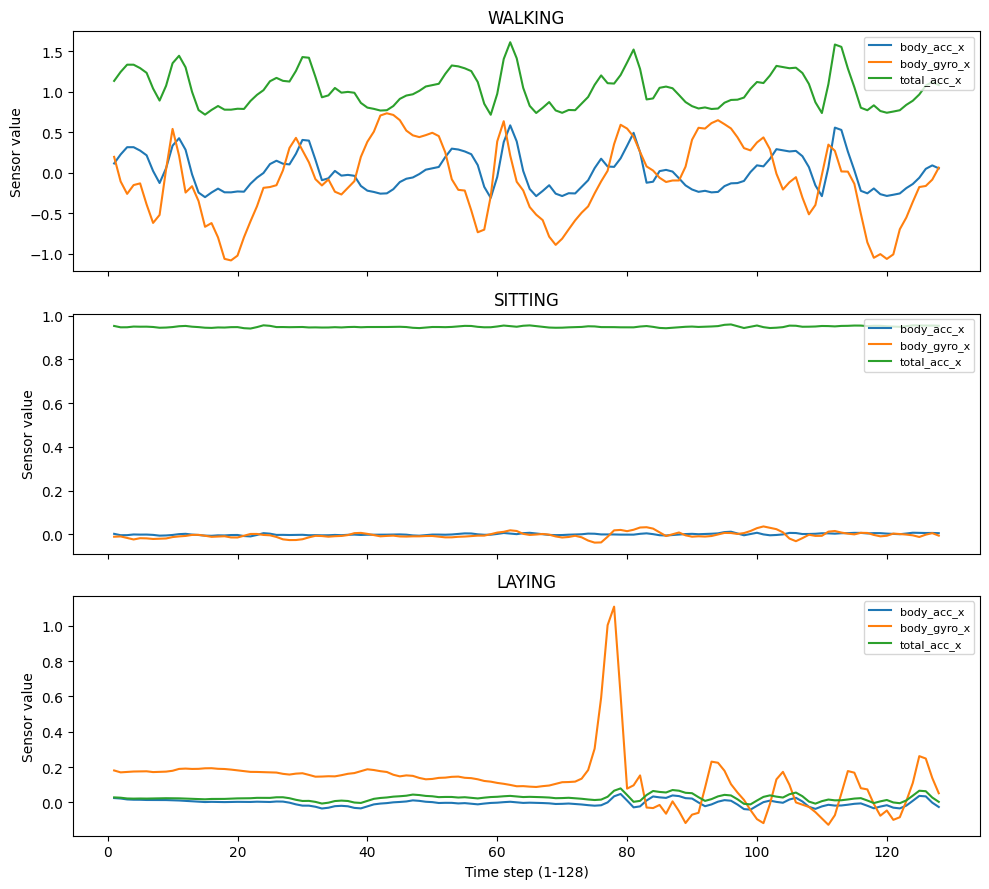

In [7]:
channels_to_plot = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x
channel_names = [SIGNAL_TYPES[i] for i in channels_to_plot]

# Pick one representative window from three different activity classes
example_classes = [0, 3, 5]  # WALKING, SITTING, LAYING
fig, axes = plt.subplots(len(example_classes), 1, figsize=(10, 9), sharex=True)

for ax, cls in zip(axes, example_classes):
    idx = np.where(y_train == cls)[0][0]
    window = X_train[idx]
    for ch, name in zip(channels_to_plot, channel_names):
        ax.plot(range(1, 129), window[:, ch], label=name)
    ax.set_title(ACTIVITY_LABELS[cls])
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.show()


## 8. Vanilla RNN Numerical Exercise (BPTT)

In [8]:
x_vals = [0.5, 0.7, 0.2]
h_prev = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

manual_hidden_states = []
for xt in x_vals:
    h_prev = math.tanh(Wx * xt + Wh * h_prev + b)
    manual_hidden_states.append(h_prev)

print("Manually computed hidden states h1, h2, h3:")
for t, h in enumerate(manual_hidden_states, start=1):
    print(f"  h{t} = {h:.6f}")

# Verification using a 1-unit SimpleRNN with the same weights
verify_model = Sequential([SimpleRNN(1, input_shape=(3, 1), activation="tanh", return_sequences=True)])
Wx_arr = np.array([[Wx]])
Wh_arr = np.array([[Wh]])
b_arr = np.array([b])
verify_model.layers[0].set_weights([Wx_arr, Wh_arr, b_arr])

x_input = np.array(x_vals).reshape(1, 3, 1)
program_hidden_states = verify_model.predict(x_input, verbose=0).reshape(-1)

print("\nProgram-computed hidden states h1, h2, h3:")
for t, h in enumerate(program_hidden_states, start=1):
    print(f"  h{t} = {h:.6f}")


Manually computed hidden states h1, h2, h3:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Program-computed hidden states h1, h2, h3:
  h1 = 0.336376
  h2 = 0.616352
  h3 = 0.599958


## 9. Model Builder (RNN / LSTM / GRU) and Training Configuration

In [9]:
T, F, N_CLASSES = X_train_n.shape[1], X_train_n.shape[2], len(ACTIVITY_LABELS)

def build_model(rnn_type, T=T, F=F, units=32, n_classes=N_CLASSES):
    model = Sequential(name=f"{rnn_type}_classifier")
    if rnn_type == "RNN":
        model.add(SimpleRNN(units, input_shape=(T, F)))
    elif rnn_type == "LSTM":
        model.add(LSTM(units, input_shape=(T, F)))
    elif rnn_type == "GRU":
        model.add(GRU(units, input_shape=(T, F)))
    else:
        raise ValueError("Unknown rnn_type")
    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

EPOCHS = 30
BATCH_SIZE = 32


## 10. Train RNN, LSTM and GRU (identical settings)

In [10]:
trained_models = {}
histories = {}
training_times = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print(f"Training {rnn_type} ...")
    model = build_model(rnn_type)
    start_time = time.time()
    hist = model.fit(
        X_train_n, y_train,
        validation_data=(X_val_n, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    elapsed = time.time() - start_time

    trained_models[rnn_type] = model
    histories[rnn_type] = hist
    training_times[rnn_type] = elapsed
    print(f"  Finished in {elapsed:.2f} s, final val_accuracy = {hist.history['val_accuracy'][-1]:.4f}")


Training RNN ...
  Finished in 27.98 s, final val_accuracy = 0.8022
Training LSTM ...
  Finished in 26.40 s, final val_accuracy = 0.9111
Training GRU ...
  Finished in 22.68 s, final val_accuracy = 0.9556


## 11. Training and Validation Curves (Plot 2 & Plot 3)

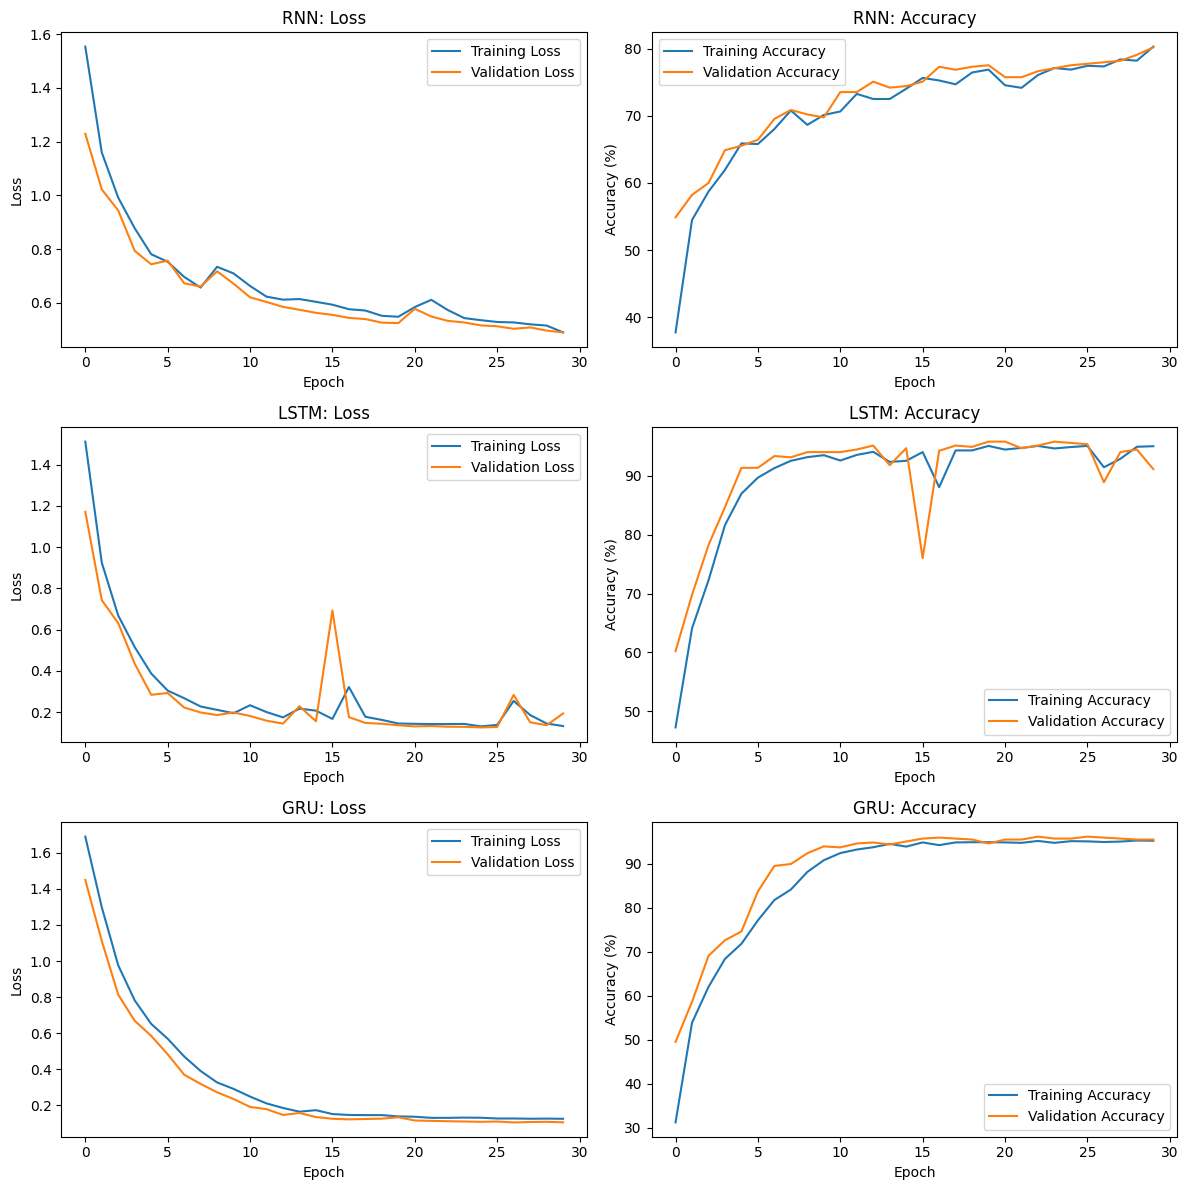

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, rnn_type in enumerate(["RNN", "LSTM", "GRU"]):
    hist = histories[rnn_type].history

    axes[row, 0].plot(hist["loss"], label="Training Loss")
    axes[row, 0].plot(hist["val_loss"], label="Validation Loss")
    axes[row, 0].set_title(f"{rnn_type}: Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].legend()

    axes[row, 1].plot(np.array(hist["accuracy"]) * 100, label="Training Accuracy")
    axes[row, 1].plot(np.array(hist["val_accuracy"]) * 100, label="Validation Accuracy")
    axes[row, 1].set_title(f"{rnn_type}: Accuracy")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Accuracy (%)")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()


## 12. Performance Evaluation on the Test Set

In [12]:
metrics_table = {}
test_predictions = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    model = trained_models[rnn_type]
    y_prob = model.predict(X_test_n, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    test_predictions[rnn_type] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    n_params = model.count_params()

    metrics_table[rnn_type] = {
        "Accuracy (%)": acc * 100,
        "Macro Precision (%)": prec * 100,
        "Macro Recall (%)": rec * 100,
        "Macro F1 (%)": f1 * 100,
        "Parameters": n_params,
        "Training Time (s)": training_times[rnn_type],
    }

metrics_df = pd.DataFrame(metrics_table).T
metrics_df


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,79.777778,78.860610,78.500611,78.536247,1974.0,27.981569
LSTM,90.444444,92.038506,91.231397,91.268706,6006.0,26.398503
GRU,94.000000,94.341747,94.320976,94.279609,4758.0,22.678539


## 13. Confusion Matrices (Plot 4)

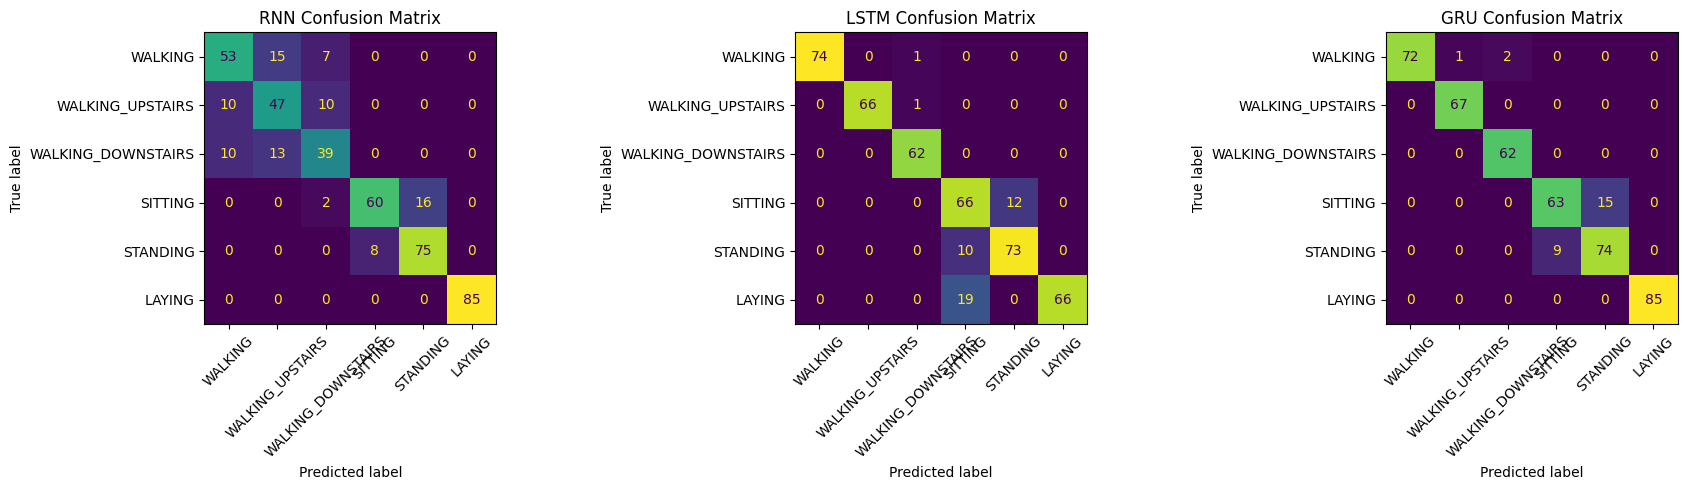

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rnn_type in zip(axes, ["RNN", "LSTM", "GRU"]):
    cm = confusion_matrix(y_test, test_predictions[rnn_type])
    disp = ConfusionMatrixDisplay(cm, display_labels=ACTIVITY_LABELS)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{rnn_type} Confusion Matrix")

plt.tight_layout()
plt.show()


## 14. RNN vs. LSTM vs. GRU Comparison Table

In [14]:
comparison_table = pd.DataFrame({
    "Hidden state": ["Yes", "Yes", "Yes"],
    "Cell state": ["No", "Yes", "No"],
    "Forget gate": ["No", "Yes", "No"],
    "Input gate": ["No", "Yes", "No"],
    "Output gate": ["No", "Yes", "No"],
    "Update gate": ["No", "No", "Yes"],
    "Reset gate": ["No", "No", "Yes"],
    "Parameters": [metrics_table[m]["Parameters"] for m in ["RNN", "LSTM", "GRU"]],
    "Training time (s)": [metrics_table[m]["Training Time (s)"] for m in ["RNN", "LSTM", "GRU"]],
    "Test F1-score (%)": [metrics_table[m]["Macro F1 (%)"] for m in ["RNN", "LSTM", "GRU"]],
}, index=["RNN", "LSTM", "GRU"])

comparison_table


,Hidden state,Cell state,Forget gate,Input gate,Output gate,Update gate,Reset gate,Parameters,Training time (s),Test F1-score (%)
RNN,Yes,No,No,No,No,No,No,1974,27.981569,78.536247
LSTM,Yes,Yes,Yes,Yes,Yes,No,No,6006,26.398503,91.268706
GRU,Yes,No,No,No,No,Yes,Yes,4758,22.678539,94.279609


## 15. Model Performance Comparison (Plot 5)

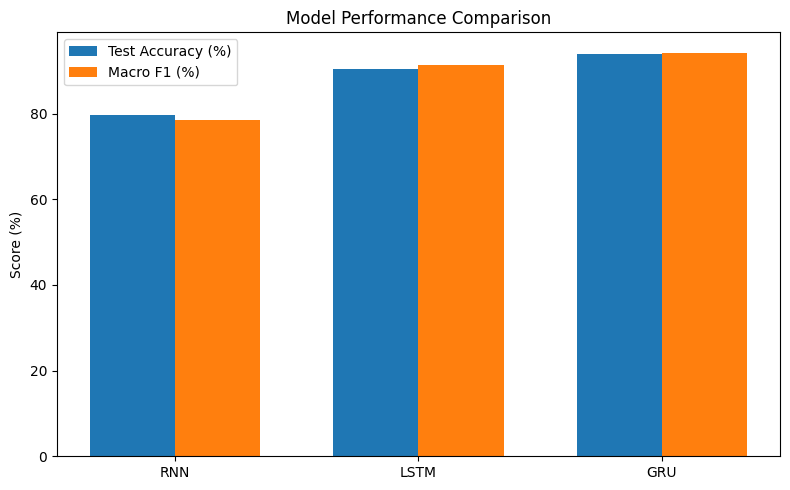

In [15]:
fig, ax1 = plt.subplots(figsize=(8, 5))

x_pos = np.arange(3)
width = 0.35
accs = [metrics_table[m]["Accuracy (%)"] for m in ["RNN", "LSTM", "GRU"]]
f1s = [metrics_table[m]["Macro F1 (%)"] for m in ["RNN", "LSTM", "GRU"]]

ax1.bar(x_pos - width / 2, accs, width, label="Test Accuracy (%)")
ax1.bar(x_pos + width / 2, f1s, width, label="Macro F1 (%)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(["RNN", "LSTM", "GRU"])
ax1.set_ylabel("Score (%)")
ax1.set_title("Model Performance Comparison")
ax1.legend()

plt.tight_layout()
plt.show()


## 16. Effect of Sequence Length (T = 32, 64, 128)

In [16]:
SEQ_LENGTHS = [32, 64, 128]
SEQLEN_EPOCHS = 15

seqlen_results = {T_len: {} for T_len in SEQ_LENGTHS}

for T_len in SEQ_LENGTHS:
    X_tr_trunc = X_train_n[:, :T_len, :]
    X_val_trunc = X_val_n[:, :T_len, :]
    X_test_trunc = X_test_n[:, :T_len, :]

    for rnn_type in ["RNN", "LSTM", "GRU"]:
        model = build_model(rnn_type, T=T_len)
        model.fit(
            X_tr_trunc, y_train,
            validation_data=(X_val_trunc, y_val),
            epochs=SEQLEN_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
        )
        y_pred = np.argmax(model.predict(X_test_trunc, verbose=0), axis=1)
        f1 = precision_recall_fscore_support(y_test, y_pred, average="macro")[2]
        seqlen_results[T_len][rnn_type] = f1 * 100
        print(f"T={T_len}, {rnn_type}: Macro F1 = {f1*100:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results).T
seqlen_df.index.name = "Sequence Length"
seqlen_df


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


T=32, RNN: Macro F1 = 71.66%


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


T=32, LSTM: Macro F1 = 92.87%


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


T=128, LSTM: Macro F1 = 91.46%


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


T=128, GRU: Macro F1 = 93.78%


,RNN,LSTM,GRU
Sequence Length,,,
32,71.657713,92.868732,91.973740
64,66.502504,95.661612,93.086694
128,73.220208,91.458552,93.780914


### Plot 6: Sequence Length vs. Test F1-score

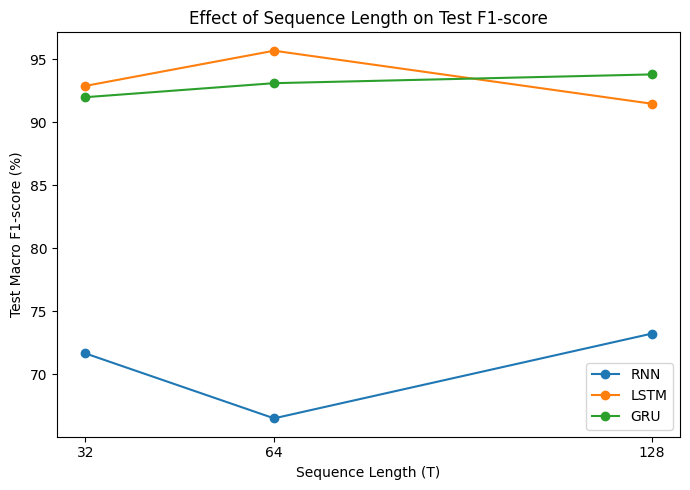

In [17]:
plt.figure(figsize=(7, 5))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    plt.plot(SEQ_LENGTHS, seqlen_df[rnn_type], marker="o", label=rnn_type)

plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Effect of Sequence Length on Test F1-score")
plt.xticks(SEQ_LENGTHS)
plt.legend()
plt.tight_layout()
plt.show()


## 17. Video Understanding Using CNN + RNN


In [18]:
import zipfile

with zipfile.ZipFile("UCF101_subset.zip", "r") as z:
    z.extractall(".")

In [19]:
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

VIDEO_DIR = "UCF101_subset"
SELECTED_CLASSES = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]
NUM_FRAMES = 10
IMG_SIZE = 224

cnn_base = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
cnn_base.trainable = False  # freeze pretrained CNN
FEATURE_DIM = cnn_base.output_shape[-1]

print("CNN feature dimension D =", FEATURE_DIM)


/tmp/ipykernel_1242/1569419908.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_base = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CNN feature dimension D = 1280


### Frame Sampling and CNN Feature Extraction

In [20]:
def sample_frames(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    target_idxs = set(np.linspace(0, max(total - 1, 0), num_frames).astype(int).tolist())

    frames = []
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in target_idxs:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        frame_idx += 1
    cap.release()

    if len(frames) == 0:
        return None
    while len(frames) < num_frames:
        frames.append(frames[-1])
    return np.array(frames[:num_frames])


def extract_video_features(video_path):
    frames = sample_frames(video_path)
    if frames is None:
        return None
    frames_pre = preprocess_input(frames.astype(np.float32))
    features = cnn_base.predict(frames_pre, verbose=0)  # (NUM_FRAMES, FEATURE_DIM)
    return features


video_features = []
video_labels = []
sample_frame_cache = {}

if os.path.isdir(VIDEO_DIR):
    for cls in SELECTED_CLASSES:
        cls_dir = os.path.join(VIDEO_DIR, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            vpath = os.path.join(cls_dir, fname)
            feats = extract_video_features(vpath)
            if feats is None:
                continue
            video_features.append(feats)
            video_labels.append(cls)
            if cls not in sample_frame_cache:
                sample_frame_cache[cls] = sample_frames(vpath)

    X_video = np.array(video_features)
    class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}
    y_video = np.array([class_to_idx[l] for l in video_labels])

    print("Video input tensor shape:", X_video.shape)
else:
    print(f"'{VIDEO_DIR}' not found. Place the UCF101 subset there before running this cell.")
    X_video, y_video = None, None


Video input tensor shape: (60, 10, 1280)


### Plot 7: Sample Frames From One Video

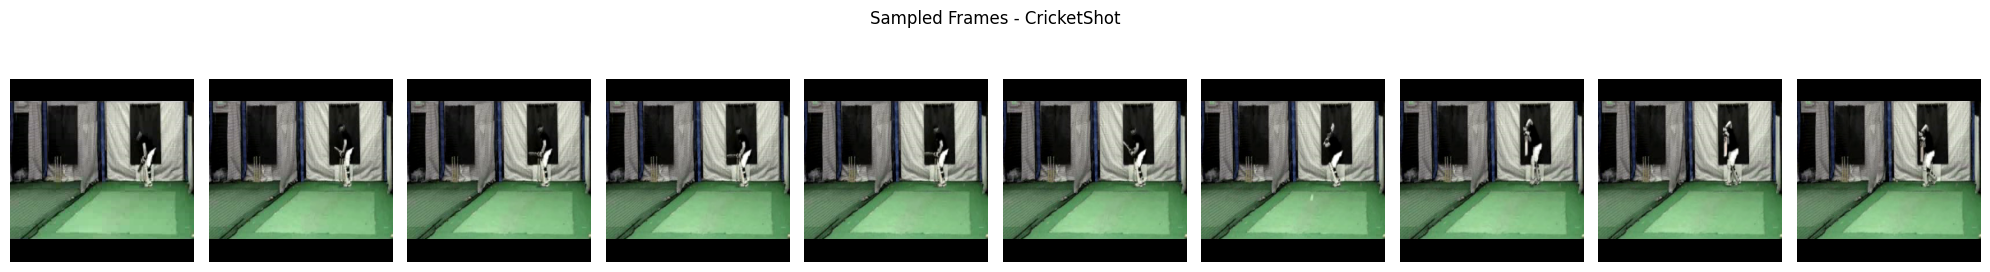

In [21]:
if sample_frame_cache:
    example_class = next(iter(sample_frame_cache))
    example_frames = sample_frame_cache[example_class]

    fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(20, 3))
    for i, ax in enumerate(axes):
        ax.imshow(example_frames[i])
        ax.axis("off")
    fig.suptitle(f"Sampled Frames - {example_class}")
    plt.tight_layout()
    plt.show()
else:
    print("No videos processed yet.")


### CNN–LSTM / CNN–GRU Classifier

In [22]:
def build_video_model(rnn_type="LSTM", units=32, num_frames=NUM_FRAMES, feature_dim=FEATURE_DIM, n_classes=len(SELECTED_CLASSES)):
    model = Sequential(name=f"CNN_{rnn_type}_video_classifier")
    if rnn_type == "LSTM":
        model.add(LSTM(units, input_shape=(num_frames, feature_dim)))
    else:
        model.add(GRU(units, input_shape=(num_frames, feature_dim)))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


if X_video is not None and len(X_video) > 0:
    Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
        X_video, y_video, test_size=0.30, stratify=y_video, random_state=42
    )
    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_temp, yv_temp, test_size=0.50, stratify=yv_temp, random_state=42
    )

    video_model = build_video_model("LSTM")
    video_history = video_model.fit(
        Xv_train, yv_train,
        validation_data=(Xv_val, yv_val),
        epochs=20,
        batch_size=8,
        verbose=0,
    )
else:
    print("Skipping video model training - no video data available.")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Plot 8: Video Training and Validation Curves

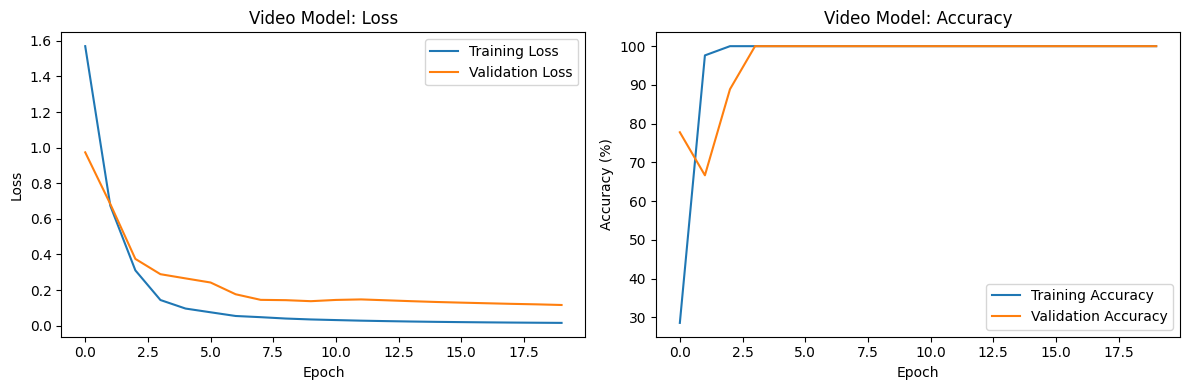

In [23]:
if X_video is not None and len(X_video) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(video_history.history["loss"], label="Training Loss")
    axes[0].plot(video_history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Video Model: Loss")
    axes[0].legend()

    axes[1].plot(np.array(video_history.history["accuracy"]) * 100, label="Training Accuracy")
    axes[1].plot(np.array(video_history.history["val_accuracy"]) * 100, label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Video Model: Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### Plot 9: Video Confusion Matrix and Sample Predictions

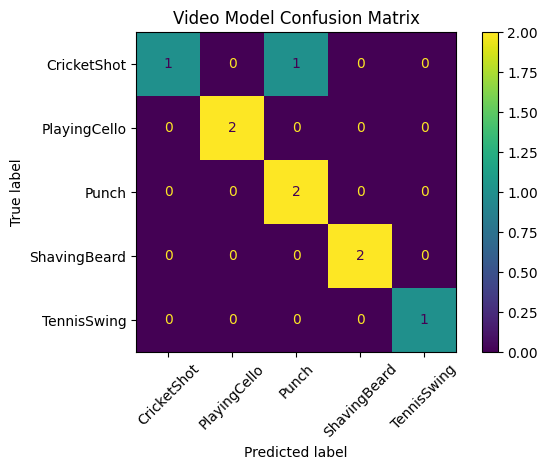


Sample predictions:
Predicted class : Punch
Actual class    : Punch
Confidence      : 0.97

Predicted class : PlayingCello
Actual class    : PlayingCello
Confidence      : 0.99

Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 0.99

Predicted class : ShavingBeard
Actual class    : ShavingBeard
Confidence      : 0.98

Predicted class : CricketShot
Actual class    : CricketShot
Confidence      : 0.68



In [24]:
if X_video is not None and len(X_video) > 0:
    yv_prob = video_model.predict(Xv_test, verbose=0)
    yv_pred = np.argmax(yv_prob, axis=1)
    yv_conf = np.max(yv_prob, axis=1)

    cm_video = confusion_matrix(yv_test, yv_pred)
    disp = ConfusionMatrixDisplay(cm_video, display_labels=SELECTED_CLASSES)
    disp.plot(xticks_rotation=45)
    plt.title("Video Model Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print("\nSample predictions:")
    for i in range(min(5, len(yv_test))):
        print(f"Predicted class : {SELECTED_CLASSES[yv_pred[i]]}")
        print(f"Actual class    : {SELECTED_CLASSES[yv_test[i]]}")
        print(f"Confidence      : {yv_conf[i]:.2f}\n")


## 18. Sequence-to-Sequence Learning (Synthetic Reversal Task)

In [25]:
SEQ_LEN = 6
VOCAB_SIZE = 10  # digits 1-9 used, 0 reserved

def generate_reversal_data(n_samples, seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.integers(1, vocab_size, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = generate_reversal_data(6000)

X_seq_train, X_seq_test, Y_seq_train, Y_seq_test = train_test_split(
    X_seq, Y_seq, test_size=0.2, random_state=42
)

print("Example:", X_seq_train[0], "->", Y_seq_train[0])
print("X_seq_train shape:", X_seq_train.shape)
print("Y_seq_train shape:", Y_seq_train.shape)


Example: [1 7 2 2 6 3] -> [3 6 2 2 7 1]
X_seq_train shape: (4800, 6)
Y_seq_train shape: (4800, 6)


### Encoder–Decoder (Seq2Seq) Model

In [26]:
def build_seq2seq(seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, units=64, emb_dim=32):
    inputs = Input(shape=(seq_len,), name="encoder_input")
    emb = Embedding(vocab_size, emb_dim, name="embedding")(inputs)

    encoder_outputs, state_h, state_c = LSTM(units, return_state=True, name="encoder_lstm")(emb)

    decoder_input = RepeatVector(seq_len, name="repeat_context")(encoder_outputs)
    decoder_outputs = LSTM(units, return_sequences=True, name="decoder_lstm")(
        decoder_input, initial_state=[state_h, state_c]
    )
    outputs = TimeDistributed(Dense(vocab_size, activation="softmax"), name="output")(decoder_outputs)

    model = Model(inputs, outputs, name="seq2seq_reversal")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

seq2seq_model = build_seq2seq()
seq2seq_model.summary()


Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 6, 32)     │        320 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_context      │ (None, 6, 64)     │          0 │ encoder_lstm[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 6, 64)     │     33,024 │ repeat_context[0… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 6, 10)     │        650 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,826 (229.79 KB)

 Trainable params: 58,826 (229.79 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Seq2Seq Model

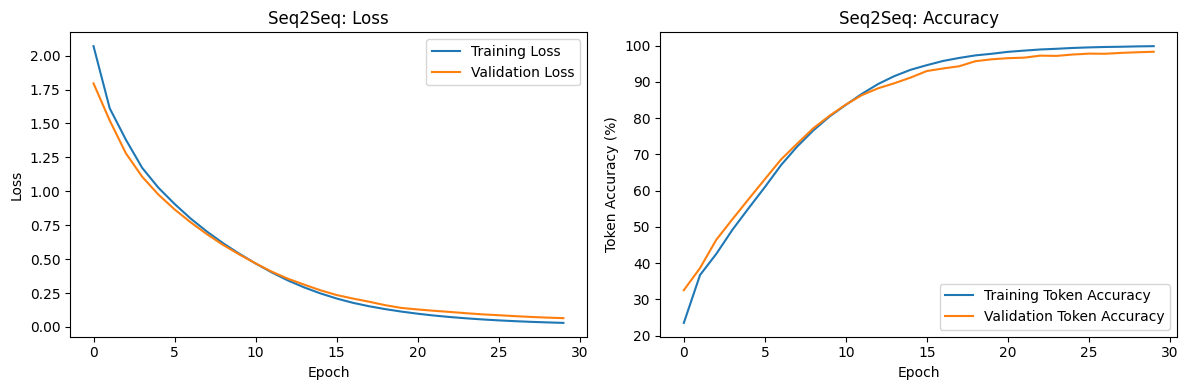

In [27]:
seq2seq_history = seq2seq_model.fit(
    X_seq_train, Y_seq_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(seq2seq_history.history["loss"], label="Training Loss")
axes[0].plot(seq2seq_history.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Seq2Seq: Loss")
axes[0].legend()

axes[1].plot(np.array(seq2seq_history.history["accuracy"]) * 100, label="Training Token Accuracy")
axes[1].plot(np.array(seq2seq_history.history["val_accuracy"]) * 100, label="Validation Token Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Token Accuracy (%)")
axes[1].set_title("Seq2Seq: Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


### Seq2Seq Evaluation: Token Accuracy and Sequence Accuracy

In [28]:
Y_pred_probs = seq2seq_model.predict(X_seq_test, verbose=0)
Y_pred = np.argmax(Y_pred_probs, axis=-1)

token_accuracy = np.mean(Y_pred == Y_seq_test)
sequence_accuracy = np.mean(np.all(Y_pred == Y_seq_test, axis=1))
final_train_loss = seq2seq_history.history["loss"][-1]
final_val_loss = seq2seq_history.history["val_loss"][-1]

print(f"Token Accuracy    : {token_accuracy:.4f}")
print(f"Sequence Accuracy : {sequence_accuracy:.4f}")
print(f"Final Training Loss   : {final_train_loss:.4f}")
print(f"Final Validation Loss : {final_val_loss:.4f}")

print("\nSample test predictions:")
sample_table = []
for i in range(5):
    sample_table.append({
        "Input Sequence": X_seq_test[i].tolist(),
        "Predicted Output": Y_pred[i].tolist(),
        "Actual Output": Y_seq_test[i].tolist(),
    })
pd.DataFrame(sample_table)


Token Accuracy    : 0.9806
Sequence Accuracy : 0.8933
Final Training Loss   : 0.0299
Final Validation Loss : 0.0647

Sample test predictions:


,Input Sequence,Predicted Output,Actual Output
0,"[7, 7, 7, 7, 2, 6]","[6, 2, 7, 7, 7, 7]","[6, 2, 7, 7, 7, 7]"
1,"[1, 2, 7, 6, 9, 6]","[6, 9, 6, 7, 2, 1]","[6, 9, 6, 7, 2, 1]"
2,"[7, 1, 7, 4, 5, 7]","[7, 5, 4, 7, 7, 7]","[7, 5, 4, 7, 1, 7]"
3,"[2, 7, 6, 9, 2, 2]","[2, 2, 9, 6, 7, 7]","[2, 2, 9, 6, 7, 2]"
4,"[8, 6, 3, 5, 3, 2]","[2, 3, 5, 3, 6, 8]","[2, 3, 5, 3, 6, 8]"


## 19. Consolidated Results

In [29]:
consolidated = pd.DataFrame({
    "Accuracy (%)": [metrics_table[m]["Accuracy (%)"] for m in ["RNN", "LSTM", "GRU"]],
    "Precision (%)": [metrics_table[m]["Macro Precision (%)"] for m in ["RNN", "LSTM", "GRU"]],
    "Recall (%)": [metrics_table[m]["Macro Recall (%)"] for m in ["RNN", "LSTM", "GRU"]],
    "F1 (%)": [metrics_table[m]["Macro F1 (%)"] for m in ["RNN", "LSTM", "GRU"]],
    "Parameters": [metrics_table[m]["Parameters"] for m in ["RNN", "LSTM", "GRU"]],
}, index=["RNN", "LSTM", "GRU"])

if X_video is not None and len(X_video) > 0:
    yv_prob_all = video_model.predict(Xv_test, verbose=0)
    yv_pred_all = np.argmax(yv_prob_all, axis=1)
    v_acc = accuracy_score(yv_test, yv_pred_all)
    v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(yv_test, yv_pred_all, average="macro")
    consolidated.loc["CNN-LSTM (video)"] = [
        v_acc * 100, v_prec * 100, v_rec * 100, v_f1 * 100, video_model.count_params()
    ]

print("Consolidated Results (HAR + Video):")
display(consolidated)

seq2seq_table = pd.DataFrame({
    "Token Accuracy": [token_accuracy],
    "Sequence Accuracy": [sequence_accuracy],
    "Training Loss": [final_train_loss],
    "Validation Loss": [final_val_loss],
}, index=["Seq2Seq (reversal task)"])

print("\nSequence-to-Sequence Results:")
display(seq2seq_table)


Consolidated Results (HAR + Video):


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
RNN,79.777778,78.860610,78.500611,78.536247,1974.0
LSTM,90.444444,92.038506,91.231397,91.268706,6006.0
GRU,94.000000,94.341747,94.320976,94.279609,4758.0
CNN-LSTM (video),88.888889,93.333333,90.000000,89.333333,168229.0



Sequence-to-Sequence Results:


,Token Accuracy,Sequence Accuracy,Training Loss,Validation Loss
Seq2Seq (reversal task),0.980556,0.893333,0.029917,0.064676
